# LightGBM Classifier
## Tercer estimador del ensemble — Clasificación Multiclase de Incontinencia Urinaria

| Paso | Acción |
|------|--------|
| 1 | Carga de datos del pipeline |
| 2 | Baseline LightGBM con validación cruzada 5-fold |
| 3 | Optimización de hiperparámetros con Optuna |
| 4 | Comparativa baseline vs tuneado |
| 5 | Métricas finales con foco en clase `urgencia` |
| 6 | Guardado del modelo tuneado |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings("ignore")

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)
from sklearn.preprocessing import LabelEncoder
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

PALETTE = {
    'none':   '#ADB5BD',
    'stress': '#4C9BE8',
    'mixed':  '#F4A261',
    'urge':   '#E63946',
}

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## Carga de datos del pipeline

Cargamos los datasets generados por el pipeline de preprocesamiento.  
Estos datos ya están escalados, balanceados con SMOTE y listos para entrenar.


In [2]:

# Rutas relativas desde notebooks/modeling/
path_data = "../data/processed/"
path_models = "../models/"
os.makedirs(path_models, exist_ok=True)

# Carga de datos
X_train = pd.read_csv(path_data + "X_train_final.csv")
y_train = pd.read_csv(path_data + "y_train_final.csv").squeeze()

X_test  = pd.read_csv(path_data + "X_test_final.csv")
y_test  = pd.read_csv(path_data + "y_test_final.csv").squeeze()

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")

print(f"\nDistribución en train (post-SMOTE):")
print(y_train.value_counts(normalize=True).mul(100).round(1))

print(f"\nDistribución en test (real):")
print(y_test.value_counts(normalize=True).mul(100).round(1))


X_train: (15540, 23)  |  y_train: (15540,)
X_test:  (1815, 23)   |  y_test:  (1815,)

Distribución en train (post-SMOTE):
target_tipo_ui
mixed     25.0
none      25.0
urge      25.0
stress    25.0
Name: proportion, dtype: float64

Distribución en test (real):
target_tipo_ui
none      53.6
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64


## ⚠️ Eliminación de variables con data leakage

Durante el EDA, el análisis de Cramér's V detectó que dos variables
presentan una asociación perfecta (V = 1.0) con el target `target_tipo_ui`:

- `ui_esfuerzo_presente`
- `ui_urgencia_presente`

Esto ocurre porque estas variables **forman parte del algoritmo clínico
con el que se construyó el propio target** en NHANES:

| ui_esfuerzo_presente | ui_urgencia_presente | target_tipo_ui |
|---------------------|---------------------|----------------|
| 1 (Sí) | 0 (No) | stress |
| 0 (No) | 1 (Sí) | urge |
| 1 (Sí) | 1 (Sí) | mixed |
| 0 (No) | 0 (No) | none |

Incluirlas en el entrenamiento constituye **data leakage** — el modelo
aprende a "hacer trampa" usando información que en un escenario real
no estaría disponible antes del diagnóstico.

**Evidencia del problema:** el baseline con estas variables obtenía
un F1-macro de 0.9758, artificialmente alto. Al eliminarlas, el
F1-macro bajó a 0.7110, que representa el rendimiento real del modelo
aprendiendo a partir de variables clínicas y demográficas genuinas.

**Conclusión:** se eliminan ambas columnas de X_train y X_test antes
de cualquier entrenamiento para garantizar que el modelo sea útil
en producción, donde estas variables no existen antes de la predicción.

In [5]:
# Eliminamos variables leaky — definen directamente el target
# El EDA detectó que ui_esfuerzo_presente y ui_urgencia_presente
# tienen Cramér's V = 1.0 porque son la base del algoritmo de clasificación
cols_leaky = ['ui_esfuerzo_presente', 'ui_urgencia_presente']

X_train = X_train.drop(columns=cols_leaky)
X_test  = X_test.drop(columns=cols_leaky)

print(f"Columnas eliminadas: {cols_leaky}")
print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test:  {X_test.shape}")
print("✅ Variables leaky eliminadas — el modelo ahora aprende patrones reales")

Columnas eliminadas: ['ui_esfuerzo_presente', 'ui_urgencia_presente']
Shape X_train: (15540, 21)
Shape X_test:  (1815, 21)
✅ Variables leaky eliminadas — el modelo ahora aprende patrones reales


## Baseline LightGBM con validación cruzada 5-fold

Entrenamos el modelo con parámetros por defecto para establecer un punto de referencia.  
Usamos `StratifiedKFold` para mantener la proporción de clases en cada fold.

**¿Por qué `class_weight='balanced'`?**  
Aunque ya aplicamos SMOTE, usar `class_weight='balanced'` añade una capa extra de  
protección para que el modelo no ignore la clase `urgencia` durante el entrenamiento.


In [6]:
# Modelo baseline
lgbm_baseline = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Validación cruzada estratificada 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    lgbm_baseline, X_train, y_train,
    cv=skf,
    scoring={
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted'
    },
    n_jobs=-1
)

print("=" * 55)
print("BASELINE — Validación cruzada 5-fold")
print("=" * 55)
print(f"\nAccuracy:    {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"F1-macro:    {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"F1-weighted: {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")

# Guardar métricas baseline para comparar después
baseline_f1_macro    = cv_results['test_f1_macro'].mean()
baseline_accuracy    = cv_results['test_accuracy'].mean()


BASELINE — Validación cruzada 5-fold

Accuracy:    0.7136 ± 0.0063
F1-macro:    0.7110 ± 0.0063
F1-weighted: 0.7110 ± 0.0063


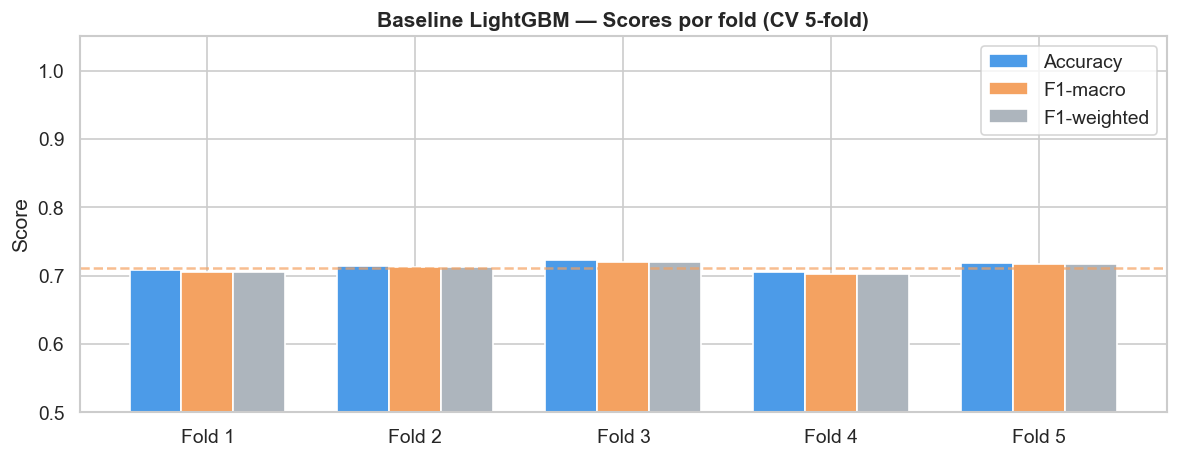

In [7]:
# Visualización de scores por fold
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(5)
width = 0.25
ax.bar(x - width, cv_results['test_accuracy'], width, label='Accuracy',    color='#4C9BE8', edgecolor='white')
ax.bar(x,         cv_results['test_f1_macro'],  width, label='F1-macro',   color='#F4A261', edgecolor='white')
ax.bar(x + width, cv_results['test_f1_weighted'], width, label='F1-weighted', color='#ADB5BD', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Baseline LightGBM — Scores por fold (CV 5-fold)', fontweight='bold')
ax.legend()
ax.axhline(baseline_f1_macro, color='#F4A261', ls='--', lw=1.5, alpha=0.7, label='Media F1-macro')

plt.tight_layout()
plt.show()


In [8]:
# Entrenamos el baseline en todo el train para ver métricas en test
lgbm_baseline.fit(X_train, y_train)
y_pred_baseline = lgbm_baseline.predict(X_test)

print("Baseline — Métricas en test:")
print(classification_report(y_test, y_pred_baseline))

# Overfitting check
train_acc_base = accuracy_score(y_train, lgbm_baseline.predict(X_train))
test_acc_base  = accuracy_score(y_test,  y_pred_baseline)
print(f"Overfitting: {(train_acc_base - test_acc_base)*100:.2f}%  {'✅ < 5%' if (train_acc_base - test_acc_base)*100 < 5 else '⚠️ > 5%'}")


Baseline — Métricas en test:
              precision    recall  f1-score   support

       mixed       0.51      0.48      0.49       328
        none       0.75      0.88      0.81       972
      stress       0.44      0.34      0.38       317
        urge       0.28      0.17      0.21       198

    accuracy                           0.64      1815
   macro avg       0.49      0.47      0.47      1815
weighted avg       0.60      0.64      0.61      1815

Overfitting: 18.53%  ⚠️ > 5%


## Paso 3 — Optimización de hiperparámetros con Optuna

**Hiperparámetros a optimizar:**
- `num_leaves` → controla la complejidad del árbol (más hojas = más complejo)
- `learning_rate` → velocidad de aprendizaje (más bajo = más preciso pero más lento)
- `n_estimators` → número de árboles
- `min_child_samples` → mínimo de muestras por hoja (evita overfitting)

**Métrica objetivo: F1-macro**  
Usamos F1-macro porque trata todas las clases por igual,  
lo que es especialmente importante para la clase minoritaria `urgencia`.


In [9]:
def objective(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'class_weight':      'balanced',
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
    }

    model = LGBMClassifier(**params)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1
    )
    return scores.mean()

# Lanzamos el estudio
print("Iniciando optimización con Optuna (50 trials)...")
print("Esto puede tardar unos minutos...\n")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Optimización completada")
print(f"Mejor F1-macro CV: {study.best_value:.4f}")
print(f"Mejores parámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Iniciando optimización con Optuna (50 trials)...
Esto puede tardar unos minutos...



  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optimización completada
Mejor F1-macro CV: 0.8054
Mejores parámetros:
  num_leaves: 141
  learning_rate: 0.13110359816053432
  n_estimators: 421
  min_child_samples: 16


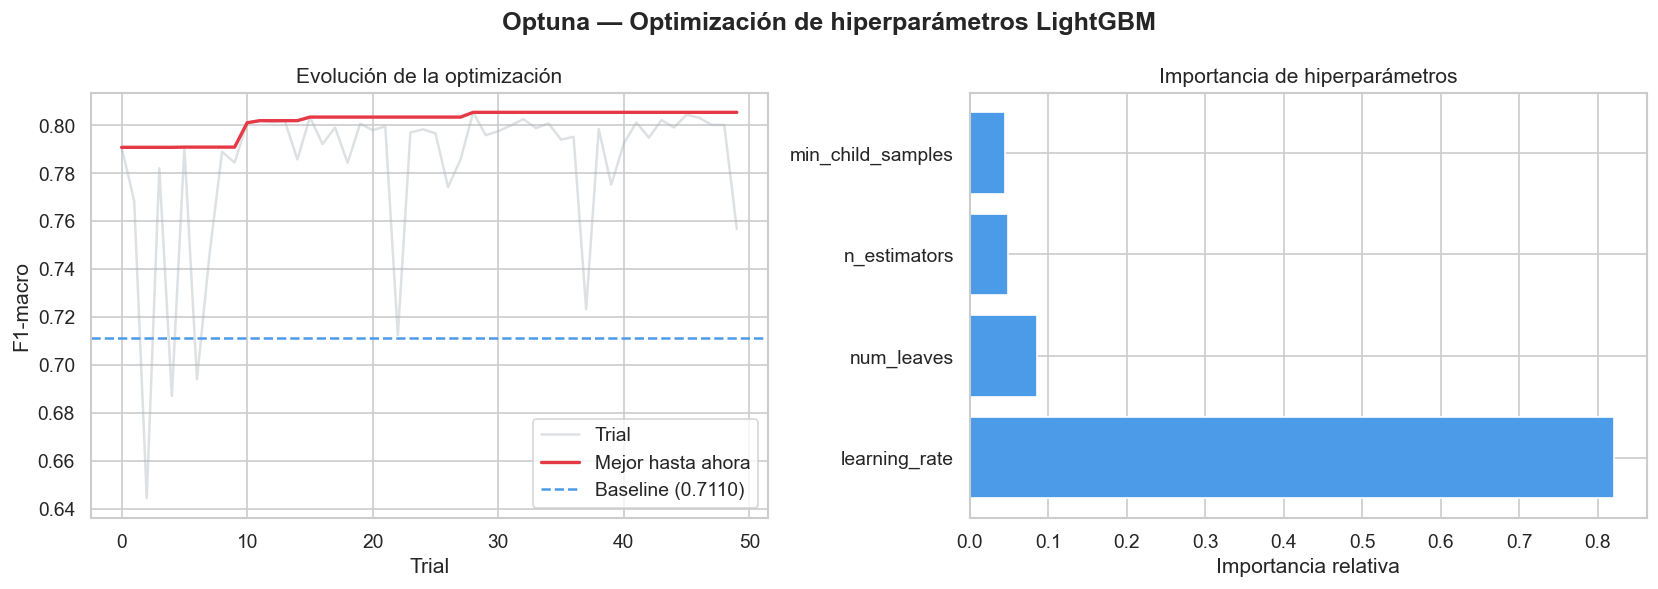

In [10]:
# Visualización de la optimización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optuna — Optimización de hiperparámetros LightGBM', fontweight='bold')

# Evolución del mejor valor
trials_values = [t.value for t in study.trials]
best_so_far   = [max(trials_values[:i+1]) for i in range(len(trials_values))]

axes[0].plot(trials_values, alpha=0.4, color='#ADB5BD', label='Trial')
axes[0].plot(best_so_far,   color='#E63946', lw=2, label='Mejor hasta ahora')
axes[0].axhline(baseline_f1_macro, color='#4C9BE8', ls='--', lw=1.5, label=f'Baseline ({baseline_f1_macro:.4f})')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F1-macro')
axes[0].set_title('Evolución de la optimización')
axes[0].legend()

# Importancia de hiperparámetros
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()),
                 color='#4C9BE8', edgecolor='white')
    axes[1].set_title('Importancia de hiperparámetros')
    axes[1].set_xlabel('Importancia relativa')
except:
    axes[1].text(0.5, 0.5, 'No disponible', ha='center', va='center')

plt.tight_layout()
plt.show()


## Paso 4 — Comparativa baseline vs modelo tuneado

Entrenamos el modelo con los mejores parámetros encontrados por Optuna  
y comparamos con el baseline.


In [11]:
# Entrenamos el modelo tuneado
best_params = study.best_params
best_params['class_weight'] = 'balanced'
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

lgbm_tuned = LGBMClassifier(**best_params)

# Validación cruzada del modelo tuneado
cv_tuned = cross_validate(
    lgbm_tuned, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted'
    },
    n_jobs=-1
)

tuned_f1_macro = cv_tuned['test_f1_macro'].mean()
tuned_accuracy = cv_tuned['test_accuracy'].mean()

print("=" * 60)
print("COMPARATIVA — Baseline vs Modelo Tuneado (CV 5-fold)")
print("=" * 60)
print(f"\n{'Métrica':<20} {'Baseline':>12} {'Tuneado':>12} {'Mejora':>10}")
print("-" * 60)
print(f"{'Accuracy':<20} {baseline_accuracy:>12.4f} {tuned_accuracy:>12.4f} {(tuned_accuracy-baseline_accuracy)*100:>+9.2f}%")
print(f"{'F1-macro':<20} {baseline_f1_macro:>12.4f} {tuned_f1_macro:>12.4f} {(tuned_f1_macro-baseline_f1_macro)*100:>+9.2f}%")


COMPARATIVA — Baseline vs Modelo Tuneado (CV 5-fold)

Métrica                  Baseline      Tuneado     Mejora
------------------------------------------------------------
Accuracy                   0.7136       0.8053     +9.17%
F1-macro                   0.7110       0.8054     +9.44%


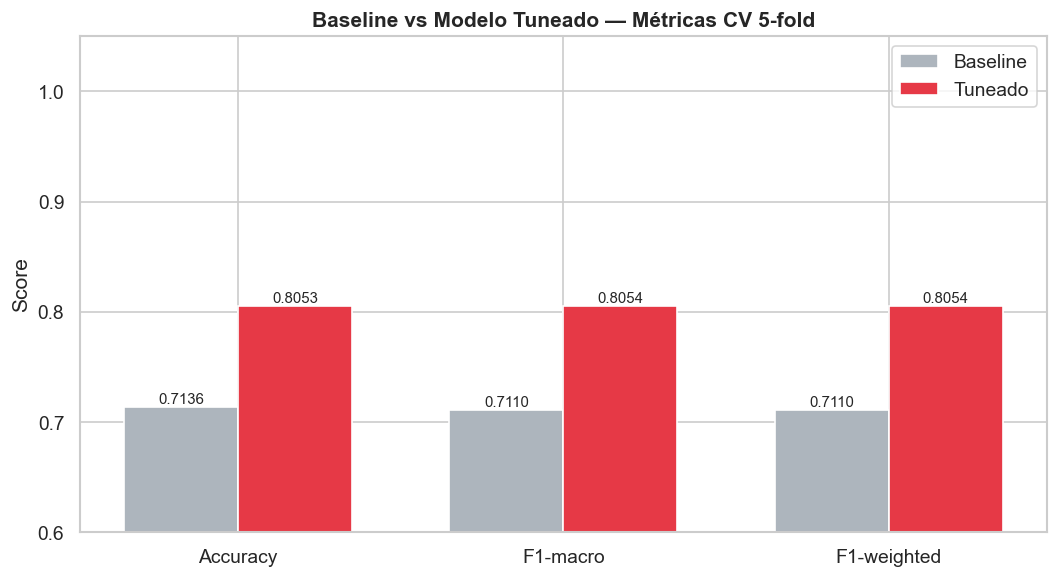

In [12]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(9, 5))

metricas = ['Accuracy', 'F1-macro', 'F1-weighted']
baseline_vals = [
    baseline_accuracy,
    baseline_f1_macro,
    cv_results['test_f1_weighted'].mean()
]
tuned_vals = [
    tuned_accuracy,
    tuned_f1_macro,
    cv_tuned['test_f1_weighted'].mean()
]

x = np.arange(len(metricas))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='#ADB5BD', edgecolor='white')
bars2 = ax.bar(x + width/2, tuned_vals,   width, label='Tuneado',  color='#E63946', edgecolor='white')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Modelo Tuneado — Métricas CV 5-fold', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


## Paso 5 — Métricas finales con foco en clase `urgencia`

Entrenamos el modelo tuneado en todo el train y evaluamos en test.  
Prestamos especial atención a la clase `urgencia` por ser la más minoritaria.


In [13]:
# Entrenamos en todo el train
lgbm_tuned.fit(X_train, y_train)
y_pred_tuned = lgbm_tuned.predict(X_test)

# Métricas generales
train_acc_tuned = accuracy_score(y_train, lgbm_tuned.predict(X_train))
test_acc_tuned  = accuracy_score(y_test,  y_pred_tuned)
overfitting     = (train_acc_tuned - test_acc_tuned) * 100

print("=" * 55)
print("MÉTRICAS FINALES — Modelo Tuneado en Test")
print("=" * 55)
print(f"\nAccuracy train: {train_acc_tuned:.4f}")
print(f"Accuracy test:  {test_acc_tuned:.4f}")
print(f"Overfitting:    {overfitting:.2f}%  {'✅ < 5%' if overfitting < 5 else '⚠️ > 5%'}")

print("\n" + classification_report(y_test, y_pred_tuned))


MÉTRICAS FINALES — Modelo Tuneado en Test

Accuracy train: 1.0000
Accuracy test:  0.6165
Overfitting:    38.35%  ⚠️ > 5%

              precision    recall  f1-score   support

       mixed       0.51      0.48      0.50       328
        none       0.76      0.84      0.80       972
      stress       0.37      0.36      0.37       317
        urge       0.24      0.16      0.19       198

    accuracy                           0.62      1815
   macro avg       0.47      0.46      0.46      1815
weighted avg       0.59      0.62      0.60      1815

